# Example 4.0 - Experiment Class - QXAS - Screen Subset of Data for XAS Processing Parameterization

    To reduce computation time for QXAS data analysis this example selectes a random (100) numerb of spectra from the QXAS dataset, then processes them in the following manner:
    1. Data Import, Absoprtion Calcualtion, Data Cleanup
    2. Reference calibration and E0 determination
    3. Spectra Normalization
    4. Spectra Interpolation and Export
    5. Pickle the Parameters Needed for Batch Processing of QXAS Data 
    6. (Optional) Save Experiment Object

    The code then deletes the subdirectory so that the data are not processed again

    The goal is to identify all the key processing paramters needed to batch process the entire QXAS dataset.

## Step 1. Import Modules

In [1]:
# File Handling
import os
import pickle

# Plot Handling
import matplotlib.pyplot as plt

# data handling
import numpy as np
import pandas as pd

# Make things interactive
import ipywidgets as widgets
from ipywidgets import interact, fixed, GridspecLayout
from IPython.display import display

# catXAS Handling:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp

%matplotlib inline

## Step 2. Definitions

In [4]:
# Data Location Definitions:

# Folder containing QXAS spectra dataset (subfolders OK)
data_dir = os.path.join(pwd, 'sample data\Raw Data')

# Create subset with n random files
subset_dir = fcts.create_random_subset(
    source_dir=data_dir,
    n_files=10 #default is 100, used 10 as data set is only 50 spectra
)

Found 50 files in 'C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample data\Raw Data'.

Copying 10 random files to 'subset of data for screening'...
✓ Successfully copied 10 files to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample data\Raw Data\subset of data for screening


In [5]:
# Output Definitions: 

# Unique name for the experiment
exp_name = 'SnO2_TPR_screening'

# Directory where to save the experiment:
pickle_dir = os.path.join(pwd, 'sample results')

# File name to save the sxperiment (must include extension '.pickle')
pickle_name = exp_name+'.pickle'

# Folder where results will be saved
output_dir = os.path.join(pwd, 'sample results')

# File name to save normalized and interpolated XAS spectra
fname_interpXAS = exp_name+'_NormXANES'

In [6]:
# Plotting Defs

Edge_Energy = 29200 # eV

emin = Edge_Energy-50 # eV

emax = Edge_Energy+50 # eV

## Step 3. Define Beamline Data Structure

Common data formats for SSRL beamlines can be found in the "BL specific XAS data structures.ipynb" notebook.

In [7]:
### Define the layout of the xas data file and how spectra are calcualted
xas_data_structure = {
    'time stamp': True,
    'time on line': 5,
    'time format': '# This Scan Create Date:\t%m/%d/%Y %I:%M:%S %p',
    'padded scan numbers': True,
    'column names': ['encoder', 'energy', 'adc_01', 'adc_02', 'adc_03', 'adc_04', 'adc_05', 'adc_06', 'adc_07', 'adc_08'],
    'energy column' : 'energy', # Energy [eV]
    'sample numerator': 'adc_01', # I0
    'sample denominator': 'adc_02', # I1
    'sample ln': True,
    'sample invert': False,
    'reference numerator': 'adc_02', # I1
    'reference denominator': 'adc_03', # I2
    'reference ln': True,
    'reference invert': False,
    'is QEXAFS': False
}

## Step 4. Add Data to Experiment Object

In [14]:
# Create the Experimental Class
my_exp = exp.Experiment(exp_name)

# Add raw data from the subset into spectra files
my_exp.import_spectra(subset_dir, xas_data_structure, ext = '.txt', print_name = False)

# Sanity Check to confirm data was imported
my_exp.summary['XAS Spectra Files']

,TOS [s],File Name,Padded Name,Path
Time,,,,
2021-06-14 16:35:37,0.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0002,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0002,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 16:40:57,320.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0005,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0005,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 16:51:30,953.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0011,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0011,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 16:53:15,1058.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0012,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0012,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 16:56:46,1269.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0014,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0014,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 17:05:37,1800.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0019,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0019,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 17:09:08,2011.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0021,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0021,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 17:17:58,2541.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0026,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0026,C:\Users\ashoff\OneDrive - SLAC National Accel...
2021-06-14 17:46:15,4238.0,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0042,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0042,C:\Users\ashoff\OneDrive - SLAC National Accel...


## Step 5. Clean up Data
    
#### STILL IN DEVELOPMENT

In [9]:
my_exp.organize_RawData(remove_duplicates=True, remove_nan_inf=False, remove_zeros=False, feedback=False, summary=True) # remove_nan_inf & remove_zeros does not work yet

Data Organized
Range of data points per raw spectra: 4980-4980
Range of data points after duplicates removed: 4838-4839
Range of data points after NaN/inf removed: 4980-4980
Range of data points after zeros removed: 4980-4980


## Step 6. Calculate Absorption Spectra

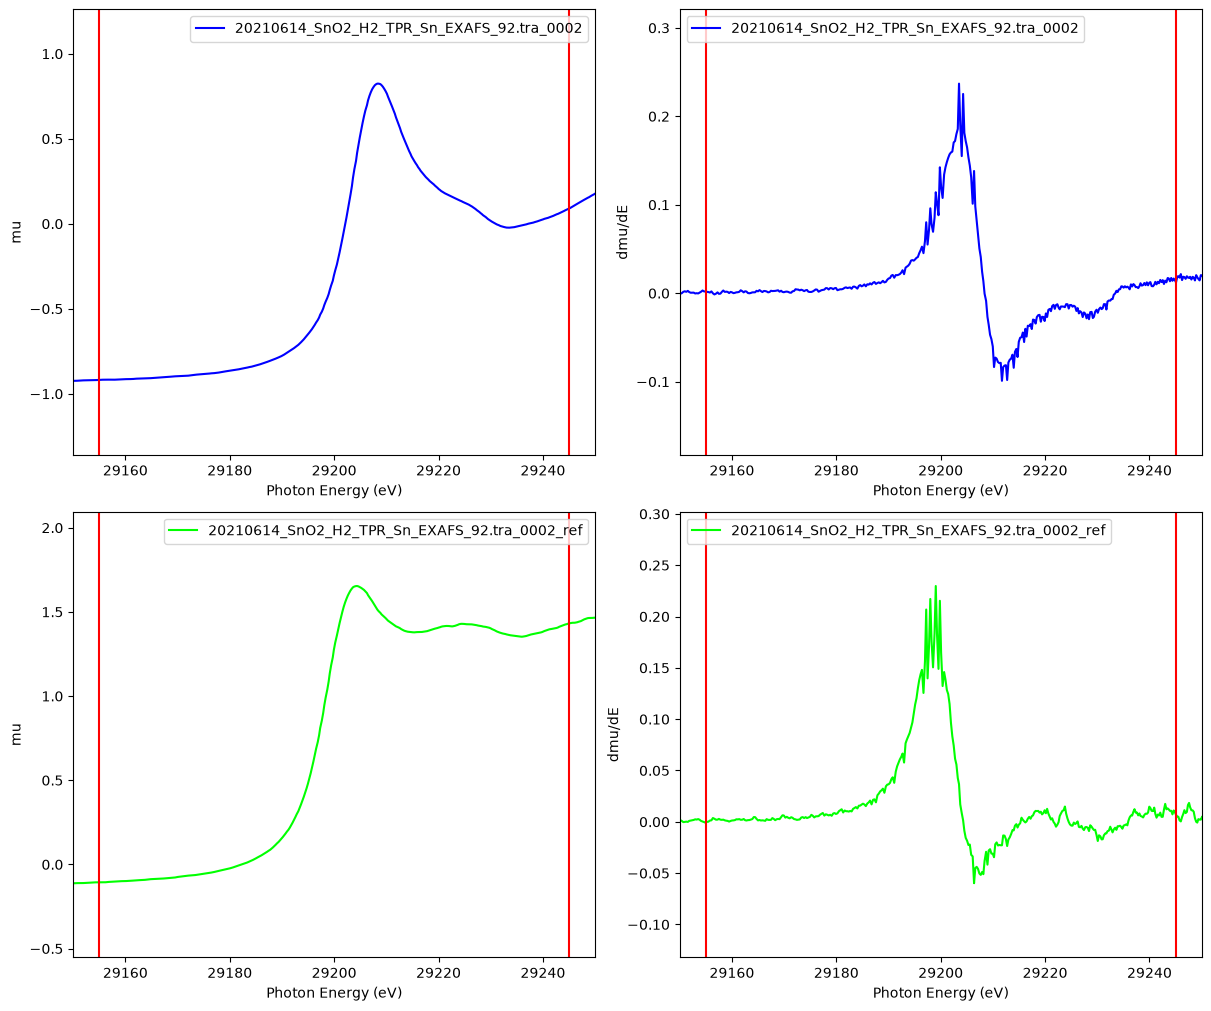

In [19]:
# Get the scan name of the first spectra imported:
scan_name = my_exp.summary['XAS Spectra Files']['File Name'].values[0]

# Calcualte mux for Sample:
sample_spectra = True

# Calcualte mux for Reference:
ref_spectra = True

# Calculate Absorptoin Spectra
my_exp.calculate_spectra(sample_spectra = sample_spectra, ref_spectra = ref_spectra)

# Visualize absorption spectra of the sample and reference for scan_name.

Samp_group = my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample']
Ref_group = my_exp.spectra[scan_name]['Absorption Spectra']['mu Reference']

pfcts.plot_XANES([Samp_group, Ref_group], emin, emax, spectra = 'mu',  
                 e0 = None, e0_line = False, ref_lines = [emin+5, emax-5], 
                 deriv = True, overlay = False,
                 filtering = True, window_length = 21, polyorder = 4)

## Step 7. Calibrate Energy and Find E0

### Reference Edge Calibration + E0 determination

In [20]:
# Option 2a: Manual edge calibration - Find the Edge

samp_ref = 'mu Reference'
spectra = 'mu'
deriv = True
e0 = None
e0_line = False 
ref_lines = (emin, emax, 0.05)
overlay = True
use_legend = False
cmap_name = 'brg'
filtering = False
window_length = 31
polyorder = 4

# Reset delE
delE_params = {'delE': 0,
              'e0': None}

# Sample
my_exp.load_params('mu Sample', delE_params)

# Reference
my_exp.load_params('mu Reference', delE_params)

interact(my_exp.plot_XANES_spectra,
         emin = fixed(emin),
         emax = fixed(emax),
         samp_ref = fixed(samp_ref),
         spectra = fixed(spectra),
         deriv = fixed(deriv),
         e0 = fixed(e0),
         e0_line = fixed(e0_line),
         ref_lines = ref_lines,
         overlay = fixed(overlay),
         use_legend = fixed(use_legend),
         cmap_name = fixed(cmap_name),
         filtering = fixed(filtering),
         window_length = fixed(window_length),
         polyorder = fixed(polyorder))

interactive(children=(FloatSlider(value=29200.0, description='ref_lines', max=29250.0, min=29150.0, step=0.05)…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>

In [21]:
# Option 2b: Manual edge calibration - Apply del E and E0

# Modify as needed:

found_edge = 29199.0

# DO NOT NEED TO MODIFY BELOW
delE = Edge_Energy-found_edge

ref_edge_params = {'delE': delE,
                   'e0': Edge_Energy}

samp_edge_params = {'delE': delE}

# Sample
my_exp.load_params('mu Sample', samp_edge_params)

# Reference
my_exp.load_params('mu Reference', ref_edge_params)

print(f'delE parameter: {delE:0.2f}')

delE parameter: 1.00


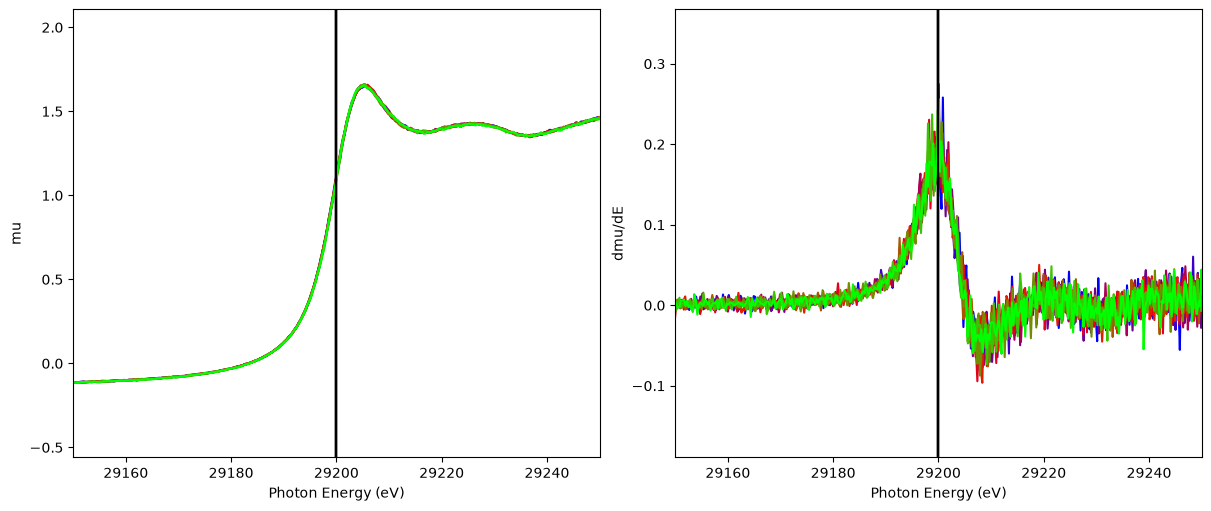

In [22]:
# Option 2b: Manual edge calibration - Check Energy Calibration with Reference Channel

my_exp.plot_XANES_spectra(emin, emax, samp_ref = 'mu Reference', spectra = 'mu', deriv = True, 
                          e0 = None, e0_line = True, 
                          ref_lines = None, overlay = True, use_legend = False, cmap_name = 'brg', 
                          filtering = False, window_length = 5, polyorder = 2)

### Find Sample E0

In [23]:
# Option 2a: Manual edge finding

# Modify as needed:


# DO NOT NEED TO MODIFY BELOw
samp_ref = 'mu Sample'
spectra = 'mu'
deriv = True
e0 = None
e0_line = False 
ref_lines = (emin, emax, 0.05)
overlay = True
use_legend = False
cmap_name = 'brg'
filtering = True
window_length = 21
polyorder = 2

interact(my_exp.plot_XANES_spectra,
         emin = fixed(emin),
         emax = fixed(emax),
         samp_ref = fixed(samp_ref),
         spectra = fixed(spectra),
         deriv = fixed(deriv),
         e0 = fixed(e0),
         e0_line = fixed(e0_line),
         ref_lines = ref_lines,
         overlay = fixed(overlay),
         use_legend = fixed(use_legend),
         cmap_name = fixed(cmap_name),
         filtering = fixed(filtering),
         window_length = fixed(window_length),
         polyorder = fixed(polyorder))

interactive(children=(FloatSlider(value=29200.0, description='ref_lines', max=29250.0, min=29150.0, step=0.05)…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>

In [24]:
# Option 2b: Manual edge finding - Apply  E0

# Modify as needed:

found_edge = 29201.5

# DO NOT NEED TO MODIFY BELOW

samp_edge_params = {'e0': found_edge}

# Sample
my_exp.load_params('mu Sample', samp_edge_params)

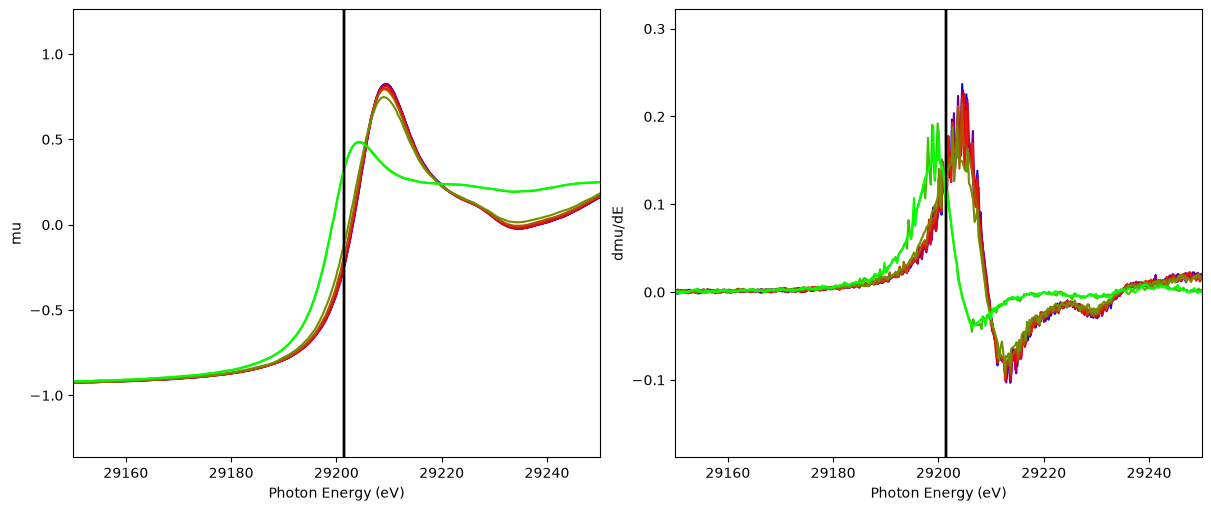

In [25]:
# Option 2b: Manual edge finding - Check Edge position of Sample Channel

my_exp.plot_XANES_spectra(emin, emax, samp_ref = 'mu Sample', spectra = 'mu', deriv = True, 
                          e0 = None, e0_line = True, 
                          ref_lines = None, overlay = True, use_legend = False, cmap_name = 'brg', 
                          filtering = True, window_length = 21, polyorder = 4)

## Step 8. Remove BL data from experimental class

In [26]:
for key in my_exp.__dict__['spectra'].keys():
    my_exp.__dict__['spectra'][key].pop('BL Data')

## Step 9. Normalize Sample Spectra

In [27]:
# Inspect each spectrum's energy range and suggest normalization paramters

df1 = my_exp.check_Energy_Range(has_e0 = True, spectra_name = 'mu Sample', print_summary = True)

Energy Range and Energy-Step Summary for mu Sample
	Variation in starting energy points between spectra [eV]: 29004.60-29004.75
	Variation in ending energy points between spectra [eV]: 30175.33-30175.45
	Variation in step size of energy points between spectra [eV]: 0.24-0.24

Normalization Parameters for mu Sample
	Edge Energy Range [E0]: 29201.50-29201.50 eV
	Pre-edge start/stop Suggestion [pre1/pre2]: -150/-50
	Post-edge start/stop Suggestion [norm1/norm2]: 75/700
	Normalizaion order Suggestion [nnorm]: 2
	Flatten Spectra Suggestion [make_norm]: True



### Normalize Sample Spectra

In [28]:
# Update values in the dictionary based upon summary results above

#Sample Normalization paramters, referenced to E0
Samp_norm_params = {'pre1': -175,
                    'pre2': -100,
                    'norm1': 120,
                    'norm2': 900,
                    'nnorm': 2,
                    'make_flat': True
                   }

my_exp.load_params('mu Sample', Samp_norm_params)

my_exp.normalize_spectra('mu Sample')


# Check Normalization
S_groups = []


for key in my_exp.spectra.keys():
    S_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Sample'])
    

interact(pfcts.plot_NormXANES,
         larch_group = S_groups)

interactive(children=(Dropdown(description='larch_group', options=(<Group '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tr…

<function plot.plot_NormXANES(larch_group)>

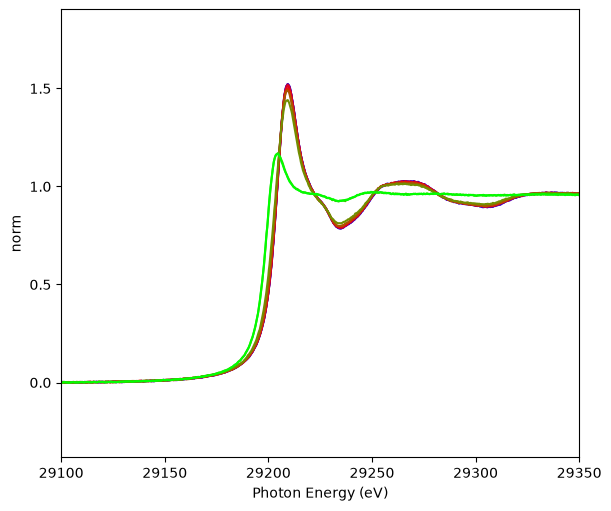

In [29]:
#. Visualization of Normalized Spectra - Sample

    
pfcts.plot_XANES(S_groups, emin-50, emax+100, spectra = 'norm', 
                 deriv = False, e0 = None, e0_line = False, 
                 overlay = True, use_legend = False)

## 10. Export Data

### Interpolated XAS spectra (XANES)

In [ ]:
df = my_exp.check_Energy_Range(has_e0 = False, spectra_name = 'mu Sample', print_summary = True)

### Perform the interpolation based upon start/stop/step size

In [ ]:
# Set the energy range and step size to interpolate onto
start = 29050
stop = 29450
step = 0.25

In [ ]:
# Interpolate Spectra
my_exp.interpolate_spectra_E(start, stop, step, sample = 'mu Sample', mu = 'flat')

In [ ]:
my_exp.__dict__['summary']['Interpolated energy']

In [ ]:
# Visualzie interpolated spectra with plot

my_exp.__dict__['summary']['Interpolated energy'].plot(legend=False)

### Save interpoalted XAS data

In [ ]:
# Save Normalized XANES:

my_exp.save_interpXAS(os.path.join(output_dir,fname_interpXAS))

## Step 11. Pickle Parameters Needed for Batch Processing of QXAS Data 

In [36]:
batch_xas_params = {
    'delE': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].delE,
    'e0': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].e0,
    'pre1': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].pre1,
    'pre2': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].pre2,
    'norm1': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].norm1,
    'norm2': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].norm2,
    'nnorm': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].nnorm,
    'make_flat': my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample'].make_flat,
}

pickle_path = os.path.join(pickle_dir,'qxas batch params.pickle')
pickle_out = open(pickle_path,"wb")
pickle.dump(batch_xas_params, pickle_out)
pickle_out.close() 

## Step 12. (OPTIONAL) Save Experiment with 'pickle'

In [33]:
pickle_path = os.path.join(pickle_dir,pickle_name)

pickle_out = open(pickle_path,"wb")
pickle.dump(my_exp, pickle_out)
pickle_out.close()

## Step 13. Delete Subdirectory of Random Spectra

In [35]:
# Step 3: Clean up - delete the subset
fcts.delete_subset(source_dir=data_dir)

✓ Successfully deleted subset: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample data\Raw Data\subset of data for screening


True